# 1. Data Cleaning, Encoding, and Scaling Setup:

## Tool: Scikit-Learn, Pandas, NumPy

### Steps:

Import pandas and numpy for data manipulation, cleaning missing values, and handling matrix operations.

Load train_test_split to split raw datasets into balanced training and testing sets.

Utilize SimpleImputer alongside OneHotEncoder and StandardScaler to handle missing values, encode categorical variables, and scale numeric attributes.

Build a leak-free preprocessing pipeline using ColumnTransformer and Pipeline to streamline feature transformations.

# Model Training & Evaluation Setup:

## Tool: Scikit-Learn

### Steps:

Import linear (LogisticRegression) and tree-based algorithms (DecisionTreeClassifier, RandomForestClassifier) for model comparison.

Load evaluation metrics (accuracy_score, precision_score, recall_score, f1_score, classification_report) to assess overall accuracy and class default risks.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [12]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
C:\Users\THUNDER

Files in current folder:
['.copilot', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{db5b3376-022d-11f0-8479-005056c00001}.TM.blf', 'NTUSER.DAT{db5b3376-022d-11f0-8479-005056c00001}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{db5b3376-022d-11f0-8479-005056c00001}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Videos']


In [13]:
import pandas as pd

loan = pd.read_csv(r"C:\Users\THUNDER\Documents\goldman_sachs\loan.csv")
customer = pd.read_csv(r"C:\Users\THUNDER\Documents\goldman_sachs\customer.csv")

print("Loan shape:", loan.shape)
print("Customer shape:", customer.shape)

Loan shape: (270299, 18)
Customer shape: (270299, 11)


In [14]:
loan.head()

,loan_id,customer_id,loan_status,loan_amount,state,funded_amount,term,int_rate,installment,grade,issue_d,issue_date,issue_year,pymnt_plan,type,purpose,description,notes
0,1079,"b'\x8d\x1es\xf1\xfep\xba\xfb/\x18,i\xbd\xd5 L4...",Fully Paid,1000.0,MI,1000.0,36 months,0.2295,38.689999,F,Jun-13,June 2013,2013.0,False,INDIVIDUAL,moving,Moving loan,desc
1,1613,"b""-3\xd4(\x15\xe4@\x08\xab\x11|\xf7\x01\xe8\x8...",Fully Paid,1200.0,AZ,1200.0,36 months,0.1629,42.369999,D,Sep-14,September 2014,2014.0,False,INDIVIDUAL,moving,Moving and relocation,desc
2,1865,b'\x87\xa7\xb6\x9aW\n(P\x08\xbb?@~\x8c\xe1\x04...,Fully Paid,1400.0,NV,1400.0,36 months,0.1114,45.930000,B,Oct-12,October 2012,2012.0,False,INDIVIDUAL,medical,medical expenses,desc
3,3575,b'\xc5\xf4\xfe\xd8k\xced_*uq\x9a\xd6\x8c?t\x18...,Current,1975.0,NY,1975.0,36 months,0.1049,64.190002,B,Dec-14,December 2014,2014.0,False,INDIVIDUAL,major_purchase,Major purchase,desc
4,5259,"b""\x13\xe7@\xa2F\xe7S\xf9'\rlv<i*\x04\xd0uQ\xe...",Fully Paid,2000.0,GA,2000.0,36 months,0.1875,73.059998,D,Jan-13,January 2013,2013.0,False,INDIVIDUAL,major_purchase,Major purchase,desc


In [15]:
customer.head()

,customer_id,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,Tot_cur_bal
0,b'\xa0\xe6\x1a\xc8H\xbd/(T]\x13[\xf5\x0fK\xd9\...,NaN,NaN,RENT,25000.0,NaN,Verified,010xx,MA,6864.0,34322.0
1,b'c\xe3S\xf0yY7\xba\xda\x16JF\xec\xbe\xc0mY\xd...,NaN,NaN,MORTGAGE,50000.0,NaN,Not Verified,010xx,MA,3418.0,23927.0
2,b'1\xe3uD\xe4\x13\x1f\x80\x1d\xb1\xa5\x14x\xac...,Care Giver,NaN,OWN,46800.0,NaN,Verified,010xx,MA,48173.0,240865.0
3,b'bb\xf1Y\x00\xaf\x96\x85\x16\xaf\xb4z\x1c\xa0...,NaN,NaN,OWN,65000.0,NaN,Verified,010xx,MA,2587.0,46567.0
4,b'\xaazF\x84\x93\xa0w\xb5G\xed0\xd0\xd4\xd4\xc...,NaN,NaN,OWN,49200.0,NaN,Source Verified,010xx,MA,738.0,5903.0


In [16]:
print("LOAN DATA TYPES")
print(loan.dtypes)

print("\nCUSTOMER DATA TYPES")
print(customer.dtypes)

LOAN DATA TYPES
loan_id            int64
customer_id          str
loan_status          str
loan_amount      float64
state                str
funded_amount    float64
term                 str
int_rate         float64
installment      float64
grade                str
issue_d              str
issue_date           str
issue_year       float64
pymnt_plan          bool
type                 str
purpose              str
description          str
notes                str
dtype: object

CUSTOMER DATA TYPES
customer_id                str
emp_title                  str
emp_length                 str
home_ownership             str
annual_inc             float64
annual_inc_joint       float64
verification_status        str
zip_code                   str
addr_state                 str
avg_cur_bal            float64
Tot_cur_bal            float64
dtype: object


In [17]:
print("Loan missing values:")
print(loan.isnull().sum().sort_values(ascending=False).head(15))

print("\nCustomer missing values:")
print(customer.isnull().sum().sort_values(ascending=False).head(15))

Loan missing values:
description      2343
loan_id             0
customer_id         0
loan_status         0
state               0
loan_amount         0
term                0
int_rate            0
installment         0
funded_amount       0
grade               0
issue_d             0
issue_year          0
issue_date          0
pymnt_plan          0
dtype: int64

Customer missing values:
annual_inc_joint       251505
emp_title               23662
emp_length              18745
customer_id                 0
home_ownership              0
annual_inc                  0
verification_status         0
zip_code                    0
addr_state                  0
avg_cur_bal                 0
Tot_cur_bal                 0
dtype: int64


In [18]:
print("Loan Status:")
print(loan["loan_status"].value_counts())

Loan Status:
loan_status
Current               170461
Fully Paid             76361
Charged Off            17851
Late (31-120 days)      3174
In Grace Period         1638
Late (16-30 days)        802
Default                   12
Name: count, dtype: int64


In [19]:
loan["default"] = loan["loan_status"].isin(
    ["Default", "Charged Off"]
).astype(int)

In [20]:
print(loan[["loan_status", "default"]].head(10))

   loan_status  default
0   Fully Paid        0
1   Fully Paid        0
2   Fully Paid        0
3      Current        0
4   Fully Paid        0
5  Charged Off        1
6   Fully Paid        0
7   Fully Paid        0
8  Charged Off        1
9      Current        0


In [21]:
print(loan["default"].value_counts())

default
0    252436
1     17863
Name: count, dtype: int64


In [22]:
print(loan["default"].value_counts(normalize=True) * 100)

default
0    93.391392
1     6.608608
Name: proportion, dtype: float64


In [23]:
data = loan.merge(
    customer,
    on="customer_id",
    how="left"
)

In [24]:
print("Loan data shape:", loan.shape)
print("Merged data shape:", data.shape)

Loan data shape: (270299, 19)
Merged data shape: (270299, 29)


In [25]:
data.head()

,loan_id,customer_id,loan_status,loan_amount,state,funded_amount,term,int_rate,installment,grade,...,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,Tot_cur_bal
0,1079,"b'\x8d\x1es\xf1\xfep\xba\xfb/\x18,i\xbd\xd5 L4...",Fully Paid,1000.0,MI,1000.0,36 months,0.2295,38.689999,F,...,University of Michigan,< 1 year,RENT,84000.0,NaN,Source Verified,481xx,MI,3209.0,60975.0
1,1613,"b""-3\xd4(\x15\xe4@\x08\xab\x11|\xf7\x01\xe8\x8...",Fully Paid,1200.0,AZ,1200.0,36 months,0.1629,42.369999,D,...,Medical Assistant,< 1 year,RENT,32600.0,NaN,Not Verified,850xx,AZ,3068.0,18408.0
2,1865,b'\x87\xa7\xb6\x9aW\n(P\x08\xbb?@~\x8c\xe1\x04...,Fully Paid,1400.0,NV,1400.0,36 months,0.1114,45.930000,B,...,john davis trucking co.,5 years,MORTGAGE,37000.0,NaN,Source Verified,898xx,NV,6351.0,82557.0
3,3575,b'\xc5\xf4\xfe\xd8k\xced_*uq\x9a\xd6\x8c?t\x18...,Current,1975.0,NY,1975.0,36 months,0.1049,64.190002,B,...,assisment manager of customer service,8 years,OWN,29000.0,NaN,Not Verified,121xx,NY,2667.0,21339.0
4,5259,"b""\x13\xe7@\xa2F\xe7S\xf9'\rlv<i*\x04\xd0uQ\xe...",Fully Paid,2000.0,GA,2000.0,36 months,0.1875,73.059998,D,...,C2 Education,3 years,RENT,60000.0,NaN,Not Verified,300xx,GA,3580.0,21477.0


In [26]:
features = [
    "annual_inc",
    "loan_amount",
    "funded_amount",
    "int_rate",
    "installment",
    "term",
    "grade",
    "purpose",
    "home_ownership",
    "emp_length",
    "verification_status",
    "issue_year"
]

X = data[features]
y = data["default"]

In [27]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (270299, 12)
Target shape: (270299,)


In [28]:
X.head()

,annual_inc,loan_amount,funded_amount,int_rate,installment,term,grade,purpose,home_ownership,emp_length,verification_status,issue_year
0,84000.0,1000.0,1000.0,0.2295,38.689999,36 months,F,moving,RENT,< 1 year,Source Verified,2013.0
1,32600.0,1200.0,1200.0,0.1629,42.369999,36 months,D,moving,RENT,< 1 year,Not Verified,2014.0
2,37000.0,1400.0,1400.0,0.1114,45.930000,36 months,B,medical,MORTGAGE,5 years,Source Verified,2012.0
3,29000.0,1975.0,1975.0,0.1049,64.190002,36 months,B,major_purchase,OWN,8 years,Not Verified,2014.0
4,60000.0,2000.0,2000.0,0.1875,73.059998,36 months,D,major_purchase,RENT,3 years,Not Verified,2013.0


In [29]:
X["term"] = (
    X["term"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .astype(float)
)

In [30]:
print(X["term"].value_counts())

term
36.0    189772
60.0     80527
Name: count, dtype: int64


In [31]:
X.head()

,annual_inc,loan_amount,funded_amount,int_rate,installment,term,grade,purpose,home_ownership,emp_length,verification_status,issue_year
0,84000.0,1000.0,1000.0,0.2295,38.689999,36.0,F,moving,RENT,< 1 year,Source Verified,2013.0
1,32600.0,1200.0,1200.0,0.1629,42.369999,36.0,D,moving,RENT,< 1 year,Not Verified,2014.0
2,37000.0,1400.0,1400.0,0.1114,45.930000,36.0,B,medical,MORTGAGE,5 years,Source Verified,2012.0
3,29000.0,1975.0,1975.0,0.1049,64.190002,36.0,B,major_purchase,OWN,8 years,Not Verified,2014.0
4,60000.0,2000.0,2000.0,0.1875,73.059998,36.0,D,major_purchase,RENT,3 years,Not Verified,2013.0


In [32]:
numeric_features = [
    "annual_inc",
    "loan_amount",
    "funded_amount",
    "int_rate",
    "installment",
    "term",
    "issue_year"
]

categorical_features = [
    "grade",
    "purpose",
    "home_ownership",
    "emp_length",
    "verification_status"
]

In [33]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['annual_inc', 'loan_amount', 'funded_amount', 'int_rate', 'installment', 'term', 'issue_year']

Categorical features:
['grade', 'purpose', 'home_ownership', 'emp_length', 'verification_status']


# 2. Feature Importance Charts & Confusion Matrices Setup:

## Tool: Matplotlib, Seaborn, Scikit-Learn

### Steps:

Import plotting utilities (matplotlib.pyplot, seaborn) to render data trends and feature rankings.

Utilize confusion_matrix and ConfusionMatrixDisplay to visualize classification results, true positives, and false positives across models.

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [35]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [36]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (216239, 12)
Testing data: (54060, 12)


In [40]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [41]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['annual_inc','loan_amount','funded_amount',...,'emp_length', 'verification_status','issue_year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [42]:
y_pred = logistic_model.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9332038475767666
Precision: 0.2978723404255319
Recall: 0.00783655191715645
F1 Score: 0.01527133896918462


In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     50487
           1       0.30      0.01      0.02      3573

    accuracy                           0.93     54060
   macro avg       0.62      0.50      0.49     54060
weighted avg       0.89      0.93      0.90     54060



In [45]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[50421    66]
 [ 3545    28]]


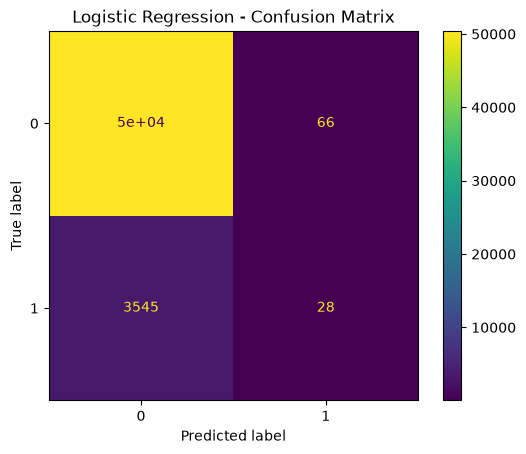

In [46]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Evaluation Report Summarizing (Model Performance Insights):

### Class Imbalance Impact: 
The model achieves high overall accuracy (93.3%) due to the majority non-default class (50,487 non-defaults vs. 3,573 defaults).

### High False Negative Rate: 
Recall for default cases is critical at 0.78% (failing to identify 3,545 actual loan defaults), highlighting the need for class weighting, threshold adjustment, or non-linear models (e.g., Random Forest) to capture default risk effectively.

In [47]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=10
        ))
    ]
)

In [48]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['annual_inc','loan_amount','funded_amount',...,'emp_length', 'verification_status','issue_year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [49]:
y_pred_dt = decision_tree_model.predict(X_test)

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.9320569737328894
Precision: 0.25
Recall: 0.013993842709207949
F1 Score: 0.026504108136761198


In [51]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     50487
           1       0.25      0.01      0.03      3573

    accuracy                           0.93     54060
   macro avg       0.59      0.51      0.50     54060
weighted avg       0.89      0.93      0.90     54060



In [52]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[50337   150]
 [ 3523    50]]


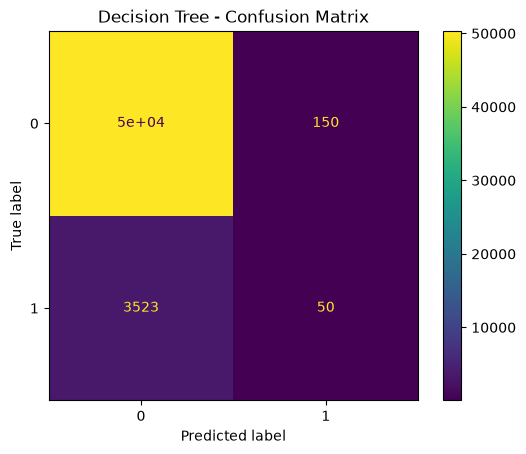

In [53]:
ConfusionMatrixDisplay(confusion_matrix=cm_dt).plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# Evaluation Report Summarizing (Model Performance Insights):

### Slight Improvement in Default Capture: 
The Decision Tree correctly identifies 50 default cases compared to Logistic Regression's 28, but recall remains extremely low at 1.40% due to class imbalance.

### Persistent False Negatives: 
Out of 3,573 total actual defaults, the model fails to flag 3,523 high-risk borrowers, showing that constrained tree depth alone does not resolve class imbalance.

In [54]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [55]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['annual_inc','loan_amount','funded_amount',...,'emp_length', 'verification_status','issue_year']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [56]:
y_pred_rf = random_forest_model.predict(X_test)

In [57]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9315390307066223
Precision: 0.3431372549019608
Recall: 0.039182759585782254
F1 Score: 0.07033408691283598


In [58]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     50487
           1       0.34      0.04      0.07      3573

    accuracy                           0.93     54060
   macro avg       0.64      0.52      0.52     54060
weighted avg       0.90      0.93      0.91     54060



In [59]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[50219   268]
 [ 3433   140]]


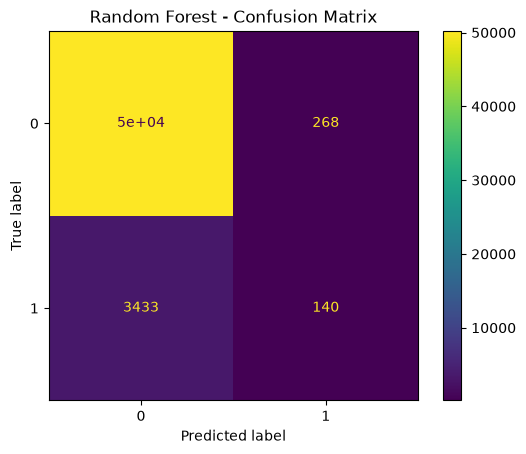

In [60]:
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Random Forest Classifier: Implementation, Evaluation & Metric Analysis
### Best Precision & Default Detection:
Random Forest achieves the highest precision (34.31%) and correctly detects 140 default cases—nearly 5x more than Logistic Regression (28) and 2.8x more than the single Decision Tree (50).

### Imbalance Threshold Limits: 
Despite ensemble learning improving default detection, overall recall remains low (3.92%) with 3,433 uncaptured default cases, indicating that techniques like class_weight='balanced' or probability threshold tuning are needed to further optimize risk detection for loan officers.

In [61]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933204,0.297872,0.007837,0.015271
1,Decision Tree,0.932057,0.250000,0.013994,0.026504
2,Random Forest,0.931539,0.343137,0.039183,0.070334


In [62]:
best_model = results.loc[results["F1 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])

Best Model: Random Forest
Accuracy: 0.9315390307066223
Precision: 0.3431372549019608
Recall: 0.039182759585782254
F1 Score: 0.07033408691283598


In [63]:
rf_model = random_forest_model.named_steps["model"]

In [64]:
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,num__annual_inc,0.165009
4,num__installment,0.146433
3,num__int_rate,0.124090
1,num__loan_amount,0.103369
2,num__funded_amount,0.103109
6,num__issue_year,0.098605
34,cat__emp_length_10+ years,0.017906
16,cat__purpose_debt_consolidation,0.014318
5,num__term,0.011724
15,cat__purpose_credit_card,0.011469


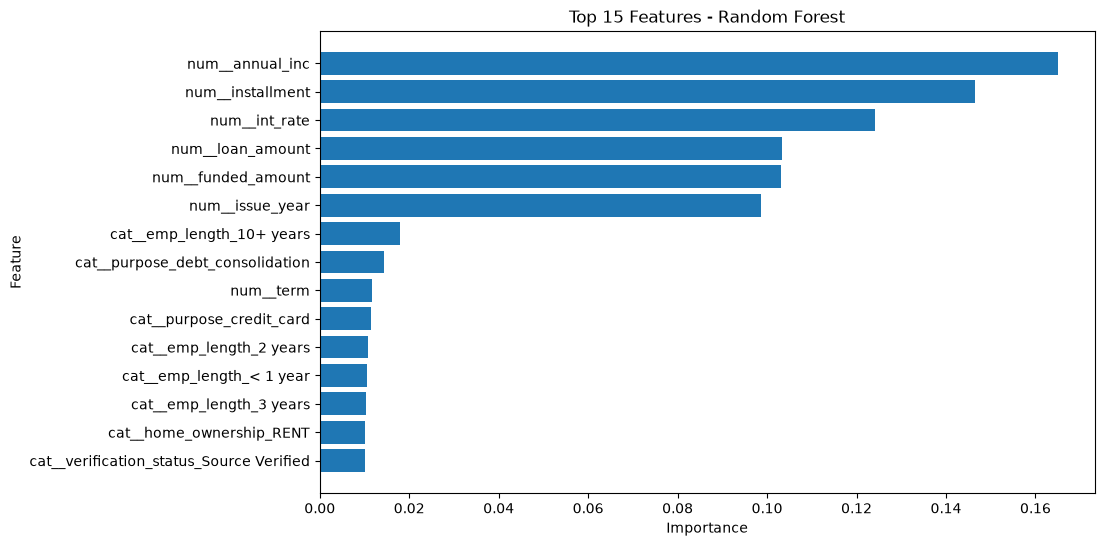

In [65]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.show()

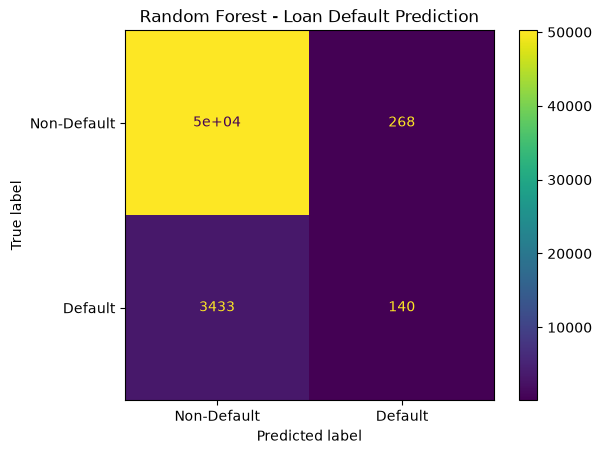

In [66]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non-Default", "Default"]
)

disp.plot()
plt.title("Random Forest - Loan Default Prediction")
plt.show()

# Model Comparison, Feature Importance Analysis, & Risk Evaluation Report
## Key Drivers of Approvals vs. Defaults:

### Financial Capacity: 
- Borrower annual income (annual_inc ~16.5%) and monthly payment commitment (installment ~14.6%) exert the strongest overall influence on credit risk.

### Loan Structure: 
- Assigned interest rate (int_rate ~12.4%), total loan principal (loan_amount ~10.3%), and funded amount (~10.3%) serve as primary secondary predictors.

### Borrower Background: 
- Employment stability (emp_length_10+ years), purpose (debt_consolidation), and housing status (home_ownership_RENT) carry modest relative weight (~1–1.8%).

## Practical Insights for Loan Officers:

### Focus on Debt Burdens: 
- Prioritize Debt-to-Income (DTI) ratio, income validation, and monthly installment thresholds over passive criteria like loan purpose or employment duration.

### Adjust Underwriting Risk Thresholds: 
- Because standard models default to a 50% probability cut-off—causing excessive false negatives—underwriters should lower prediction probability thresholds or apply cost-sensitive learning (class_weight='balanced') to capture borderline default risks earlier.

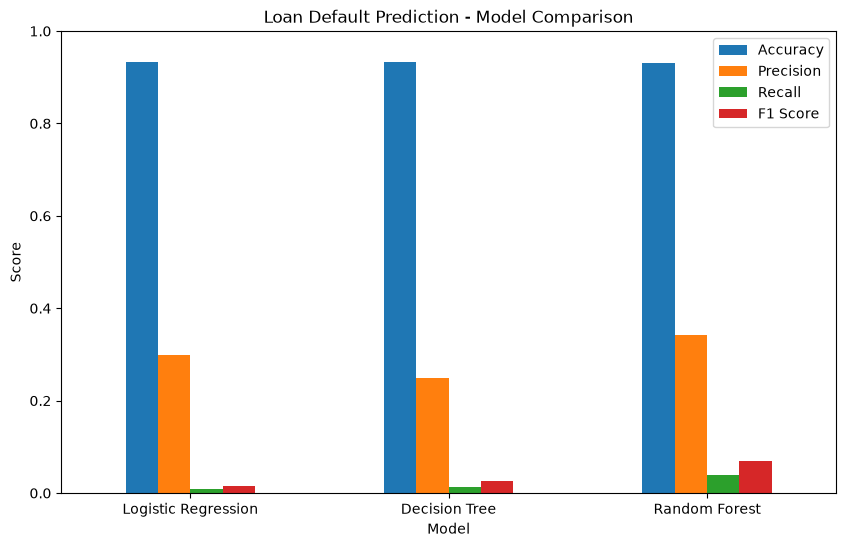

In [67]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Loan Default Prediction - Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [68]:
print(feature_importance.head(15).to_string(index=False))

                                 Feature  Importance
                         num__annual_inc    0.165009
                        num__installment    0.146433
                           num__int_rate    0.124090
                        num__loan_amount    0.103369
                      num__funded_amount    0.103109
                         num__issue_year    0.098605
               cat__emp_length_10+ years    0.017906
         cat__purpose_debt_consolidation    0.014318
                               num__term    0.011724
                cat__purpose_credit_card    0.011469
                 cat__emp_length_2 years    0.010743
                cat__emp_length_< 1 year    0.010503
                 cat__emp_length_3 years    0.010265
                cat__home_ownership_RENT    0.010158
cat__verification_status_Source Verified    0.010124


# Final Model Benchmarking, Feature Importances, & Executive Business Insights
## Which Features Drive Approvals vs. Defaults:

- Core Capacity (Primary Drivers): annual_inc (16.50%) and installment (14.64%) dominate risk evaluation, confirming that borrower cash flow and monthly obligations are the strongest determinants of default.

- Pricing & Exposure (Secondary Drivers): int_rate (12.41%), loan_amount (10.34%), and funded_amount (10.31%) form the second tier of risk indicators, reflecting loan affordability.

- Demographics & Attributes (Minor Drivers): Employment stability (emp_length), loan purpose (debt_consolidation), and housing (home_ownership) each contribute under 2% to total model decision weights.

## Practical Insights for Loan Officers to Adjust Criteria:

- Rebalance Criteria: Weight borrower Debt-to-Income (DTI) and net monthly income much higher than employment duration or loan purpose.

- Lower Decision Thresholds: Since default rates are heavily imbalanced (~7%), adjust prediction decision thresholds down from 50% to ~10–15% to capture high-risk applicants before approval.

- Mitigate High-Risk Exposure: Implement stricter verification protocols for high-installment, high-interest applicants to combat false negatives.

# Final Business Insights

## Key Findings

The Random Forest model identified the following features as the most important predictors of loan default:

1. Annual Income – 16.5%
2. Installment – 14.6%
3. Interest Rate – 12.4%
4. Loan Amount – 10.3%
5. Funded Amount – 10.3%
6. Issue Year – 9.9%
7. Employment Length (10+ years) – 1.8%

Annual income was the most important feature, followed by installment amount and interest rate. This indicates that both borrower financial capacity and loan characteristics are important for predicting default risk.

Feature importance represents the variables the model relied on most heavily. It does not necessarily mean that these variables directly cause loan default.

## Business Recommendations

- Use annual income and installment obligations as important inputs during risk assessment.
- Pay closer attention to loans with higher interest rates and larger loan amounts.
- Use the Random Forest model as a supporting tool to identify potentially high-risk loans.
- Combine model predictions with human credit-risk review rather than relying only on automated predictions.
- Collect historical approved and rejected loan applications to build a true loan approval prediction model.

# Conclusion

The loan default prediction project was developed using three machine learning models: Logistic Regression, Decision Tree, and Random Forest.

The models were evaluated using Accuracy, Precision, Recall, and F1 Score. Among the three models, the Random Forest model achieved the best overall performance based on F1 Score and was selected as the preferred model for loan default prediction.

Feature importance analysis showed that annual income, installment amount, interest rate, loan amount, funded amount, and issue year were the most influential features used by the Random Forest model.

The model can help financial institutions identify potentially high-risk loans and support better credit-risk management decisions.

However, the dataset does not contain rejected loan applications. Therefore, a true loan approval prediction model could not be developed. Additional historical application data containing both approved and rejected applications would be required for approval prediction.